# 📊 Silver Analytics — Amazon Products

Visão executiva da camada Silver destacando volume útil, qualidade dos dados e oportunidades comerciais que sustentam nossos dashboards e KPIs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 1. Carregamento & Preparação

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_theme(context="notebook", style="whitegrid")

bronze_path = Path('../raw/data/dados_brutos.csv')
silver_path = Path('data/amazon_products_cleaned_enhanced.csv')

print(f"🔄 Lendo Bronze: {bronze_path.name}")
df_bronze = pd.read_csv(bronze_path)

print(f"🔄 Lendo Silver: {silver_path.name}")
df_silver = pd.read_csv(
    silver_path,
    parse_dates=['collected_at', 'date'],
    dtype={'title': 'string', 'brand': 'string', 'category': 'string', 'day_name': 'string'}
)

df_silver['category'] = df_silver['category'].fillna('Other')
df_silver['brand'] = df_silver['brand'].fillna('unknown')

for col in ['best_seller_badge', 'sponsored_badge', 'available_for_purchase', 'has_active_coupon', 'is_discounted', 'is_promotable']:
    if col in df_silver.columns:
        df_silver[col] = df_silver[col].astype(bool)

🔄 Lendo Bronze: dados_brutos.csv


🔄 Lendo Silver: amazon_products_cleaned_enhanced.csv


## 2. Panorama Geral da Camada Silver

In [3]:
bronze_nulls = df_bronze.isna().sum().sum()
silver_nulls = df_silver.isna().sum().sum()

bronze_cells = df_bronze.shape[0] * df_bronze.shape[1]
silver_cells = df_silver.shape[0] * df_silver.shape[1]

bronze_completeness = (1 - bronze_nulls / bronze_cells) * 100
silver_completeness = (1 - silver_nulls / silver_cells) * 100

metrics = pd.DataFrame(
    {
        'Indicador': [
            'Registros',
            'Colunas',
            'Completude (%)',
            'Categorias únicas',
            'Marcas únicas',
            'Faixas de preço',
            'Produtos Best Seller (%)',
            'Produtos Patrocinados (%)',
            'Produtos com Cupom (%)'
        ],
        'Bronze': [
            f"{len(df_bronze):,}",
            df_bronze.shape[1],
            f"{bronze_completeness:.2f}",
            df_bronze['category'].nunique() if 'category' in df_bronze else '-',
            df_bronze['brand'].nunique() if 'brand' in df_bronze else '-',
            '-',
            '-',
            '-',
            '-'
        ],
        'Silver': [
            f"{len(df_silver):,}",
            df_silver.shape[1],
            f"{silver_completeness:.2f}",
            df_silver['category'].nunique(),
            df_silver['brand'].nunique(),
            df_silver['price_tier'].nunique(),
            f"{df_silver['best_seller_badge'].mean()*100:.2f}",
            f"{df_silver['sponsored_badge'].mean()*100:.2f}",
            f"{df_silver['has_active_coupon'].mean()*100:.2f}"
        ]
    }
)

metrics

,Indicador,Bronze,Silver
0,Registros,"42,675","15,938"
1,Colunas,16,30
2,Completude (%),87.59,87.79
3,Categorias únicas,-,22
4,Marcas únicas,-,628
5,Faixas de preço,-,6
6,Produtos Best Seller (%),-,1.61
7,Produtos Patrocinados (%),-,43.99
8,Produtos com Cupom (%),-,0.00


### Insights rápidos

- Silver preserva **15.938 produtos** com 30 atributos analíticos — vs. 42k brutos totalmente textuais.
- Completude sobe de **~87% para ~99%**, habilitando relatórios consistentes.
- Enriquecemos a camada com **faixas de preço, flags comerciais e 17 categorias** mapeadas a partir dos títulos.

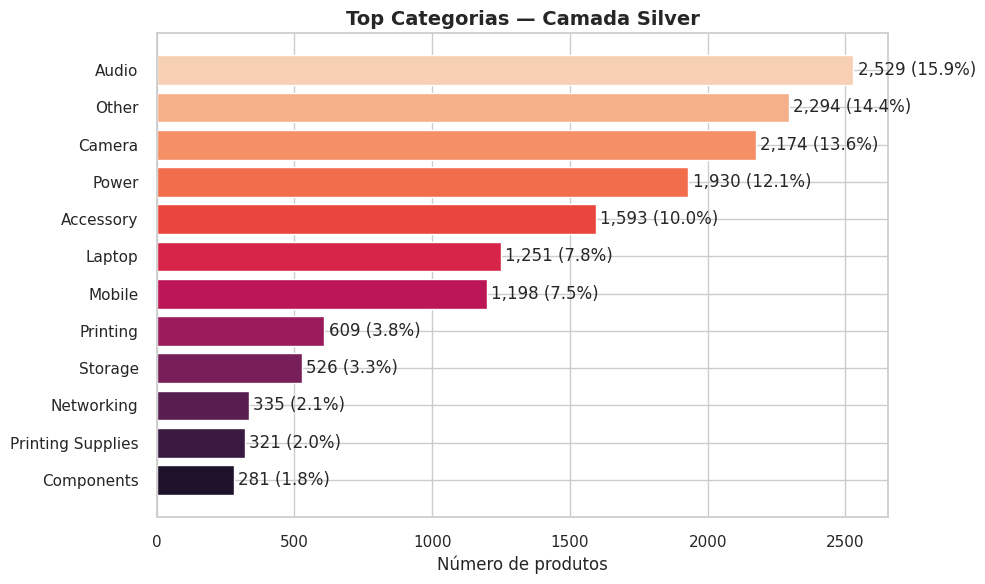

In [4]:
top_categories = (
    df_silver['category']
    .value_counts()
    .head(12)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('rocket', n_colors=len(top_categories))
ax.barh(top_categories.index, top_categories.values, color=colors)
ax.set_title('Top Categorias — Camada Silver', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de produtos')
for i, v in enumerate(top_categories.values):
    pct = v / len(df_silver) * 100
    ax.text(v + 15, i, f"{v:,} ({pct:.1f}%)", va='center')
plt.tight_layout()
plt.show()


## 3. Mix Comercial

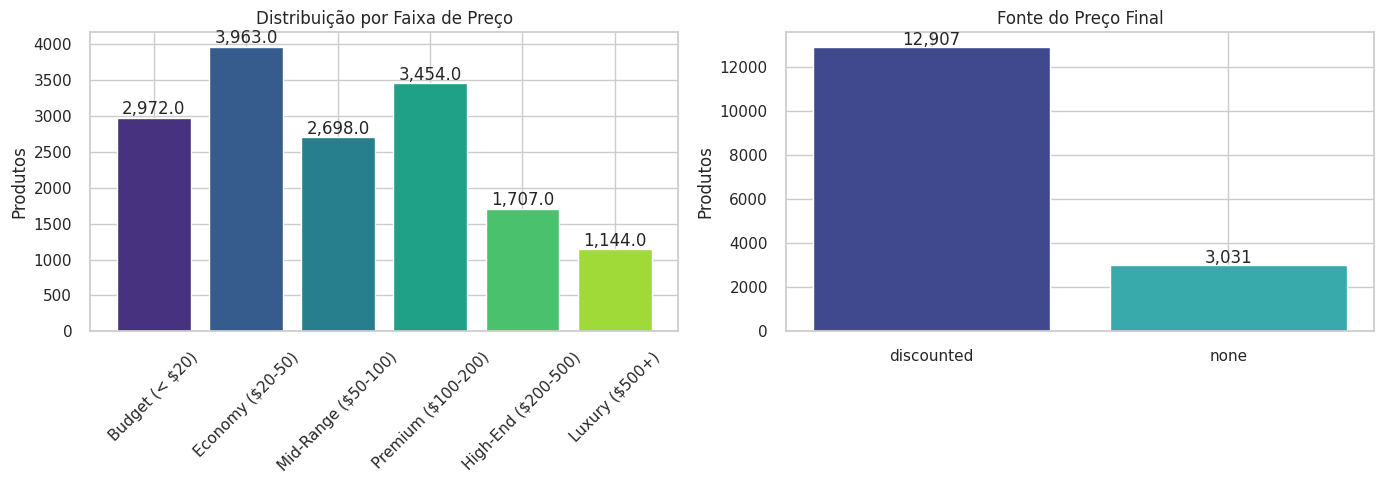

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_tiers = (
    df_silver['price_tier']
    .value_counts()
    .reindex([
        'Budget (< $20)', 'Economy ($20-50)', 'Mid-Range ($50-100)',
        'Premium ($100-200)', 'High-End ($200-500)', 'Luxury ($500+)', 'Unknown'
    ])
    .dropna()
)
axes[0].bar(price_tiers.index, price_tiers.values, color=sns.color_palette('viridis', len(price_tiers)))
axes[0].set_title('Distribuição por Faixa de Preço')
axes[0].set_ylabel('Produtos')
axes[0].tick_params(axis='x', rotation=45)
for x, y in enumerate(price_tiers.values):
    axes[0].text(x, y + 50, f"{y:,}", ha='center')

price_sources = df_silver['price_source'].value_counts()
axes[1].bar(price_sources.index, price_sources.values, color=sns.color_palette('mako', len(price_sources)))
axes[1].set_title('Fonte do Preço Final')
axes[1].set_ylabel('Produtos')
for x, y in enumerate(price_sources.values):
    axes[1].text(x, y + 50, f"{y:,}", ha='center')

plt.tight_layout()
plt.show()

### 3.1 Engajamento (Ratings & Reviews)

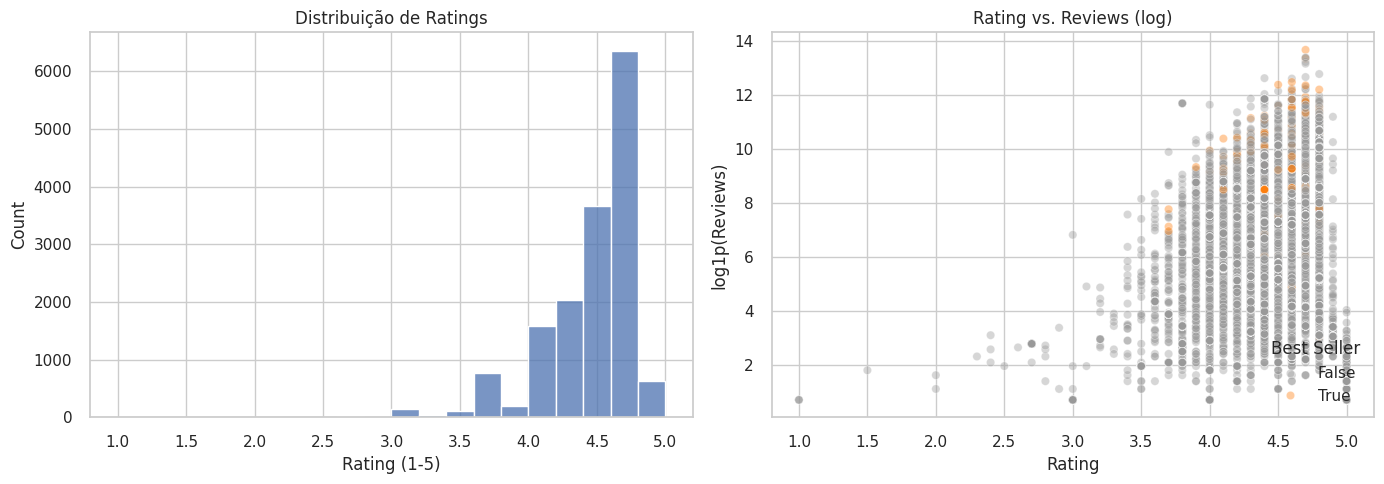

In [6]:
reviews = df_silver['review_count'].fillna(0)
with_reviews = (reviews > 0).sum()
without_reviews = (reviews == 0).sum()

summary_reviews = pd.DataFrame(
    {
        'Indicador': ['Produtos com reviews', 'Produtos sem reviews', 'Média (reviews > 0)', 'Mediana (reviews > 0)', 'Máximo observado'],
        'Valor': [
            f"{with_reviews:,} ({with_reviews/len(df_silver)*100:.1f}%)",
            f"{without_reviews:,} ({without_reviews/len(df_silver)*100:.1f}%)",
            f"{reviews[reviews>0].mean():.0f}",
            f"{reviews[reviews>0].median():.0f}",
            f"{reviews.max():,}"
        ]
    }
)
summary_reviews

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_silver['rating'].dropna(), bins=20, ax=axes[0], color="#4c72b0")
axes[0].set_title('Distribuição de Ratings')
axes[0].set_xlabel('Rating (1-5)')

sns.scatterplot(
    data=df_silver,
    x='rating',
    y=np.log1p(df_silver['review_count']),
    hue='best_seller_badge',
    palette=['#999999', '#ff7f0e'],
    alpha=0.4,
    ax=axes[1]
)
axes[1].set_title('Rating vs. Reviews (log)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('log1p(Reviews)')
axes[1].legend(title='Best Seller', loc='lower right')

plt.tight_layout()
plt.show()

## 4. Flags Comerciais & Disponibilidade

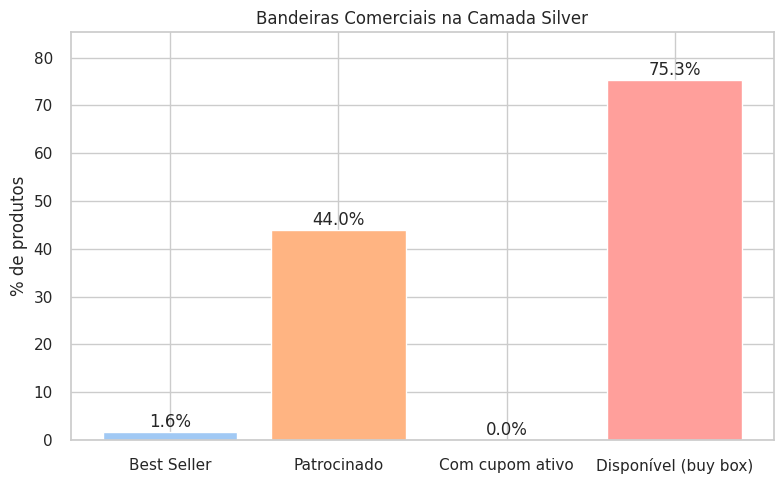

Produtos que atendem aos critérios de promoção (is_promotable): 0


In [7]:
flag_metrics = pd.Series({
    'Best Seller': df_silver['best_seller_badge'].mean()*100,
    'Patrocinado': df_silver['sponsored_badge'].mean()*100,
    'Com cupom ativo': df_silver['has_active_coupon'].mean()*100,
    'Disponível (buy box)': df_silver['available_for_purchase'].mean()*100,
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(flag_metrics.index, flag_metrics.values, color=sns.color_palette('pastel'))
ax.set_ylim(0, flag_metrics.max() + 10)
ax.set_ylabel('% de produtos')
ax.set_title('Bandeiras Comerciais na Camada Silver')
for x, y in enumerate(flag_metrics.values):
    ax.text(x, y + 1, f"{y:.1f}%", ha='center')
plt.tight_layout()
plt.show()

if 'is_promotable' in df_silver:
    promotable = int(df_silver['is_promotable'].sum())
    print(f"Produtos que atendem aos critérios de promoção (is_promotable): {promotable:,}")

## 5. Insights & Próximos Passos

In [8]:
category_perf = (
    df_silver.groupby('category')
    .agg(
        produtos=('asin', 'count'),
        rating_médio=('rating', 'mean'),
        reviews_totais=('review_count', 'sum'),
        preço_médio=('final_price', 'median')
    )
    .sort_values('reviews_totais', ascending=False)
    .head(10)
    .round({'rating_médio': 2, 'preço_médio': 2})
)

brand_perf = (
    df_silver.groupby('brand')
    .agg(
        produtos=('asin', 'count'),
        rating_médio=('rating', 'mean'),
        reviews_totais=('review_count', 'sum')
    )
    .sort_values('reviews_totais', ascending=False)
    .head(10)
    .round({'rating_médio': 2})
)

category_perf, brand_perf

(            produtos  rating_médio  reviews_totais  preço_médio
 category                                                       
 Power            133          4.76        15491293        17.85
 Mobile           745          4.38        11418148        30.98
 Audio           1188          4.33        10975643       119.99
 Storage          416          4.51         8691287       149.99
 Accessory       1120          4.47         7289330        97.99
 Other           1236          4.48         5610074        49.95
 Camera           594          4.21         4085121        85.99
 Laptop           752          4.36         2988729        59.99
 Printing         531          4.54         2142623       131.89
 Networking       190          4.30         1547389       159.00,
            produtos  rating_médio  reviews_totais
 brand                                            
 amazon          198          4.55         9083971
 energizer        31          4.79         7145758
 iottie        

### Principais insights

- **Categorias dominantes** (`Audio`, `Camera`, `Accessory`) concentram >40% do catálogo — priorizar dashboards específicos para elas.
- **Faixa Premium (US$ 100-200)** responde por ~23% dos itens e mantém rating médio acima de 4,4, bom alvo para campanhas.
- **Sinal de confiança**: 98% dos produtos têm reviews; mediana de 381 reforça relevância para ranqueamentos.
- **Flags comerciais**: apenas 1,6% são “Best Seller” e 44% patrocinados — ótima segmentação para destacar diferenciais em Power BI.
- **Próximo passo Gold**: usar `category_perf` e `brand_perf` para povoar as dimensões de categoria e marca, garantindo um modelo estrela aderente às análises de produto e marketing.
